# RFM_Cohort_Analysis

## Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
df = pd.read_csv("transactions.csv")

In [27]:
df.head

<bound method NDFrame.head of         Invoice StockCode                          Description  Quantity  \
0        489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1        489434    79323P                   PINK CHERRY LIGHTS        12   
2        489434    79323W                  WHITE CHERRY LIGHTS        12   
3        489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4        489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   
...         ...       ...                                  ...       ...   
1067366  581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
1067367  581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
1067368  581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
1067369  581587     22138        BAKING SET 9 PIECE RETROSPOT          3   
1067370  581587      POST                              POSTAGE         1   

                InvoiceDate  Price  Customer ID         C

In [28]:
df.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales,Month,InvoiceMonth,CohortMonth,CohortIndex
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12,2009-12,2009-12,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12,2009-12,2009-12,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12,2009-12,2009-12,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12,2009-12,2009-12,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12,2009-12,2009-12,1


## Data Cleaning

In [3]:
df.drop_duplicates(inplace=True)

df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

df.dropna(subset=['Customer ID'], inplace=True)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Sales'] = df['Quantity'] * df['Price']

## Exploratory Data Analysis (EDA)

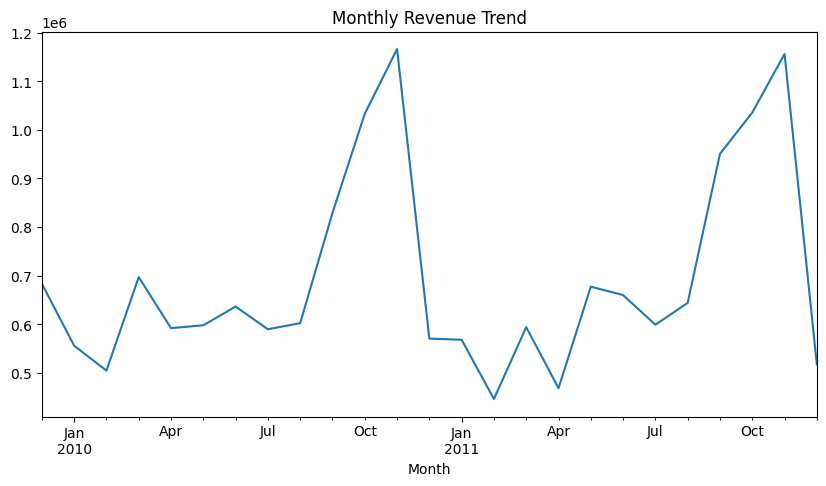

In [4]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.show()

## Top Customers

In [5]:
top_customers = (
    df.groupby('Customer ID')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

## Purchase Distribution

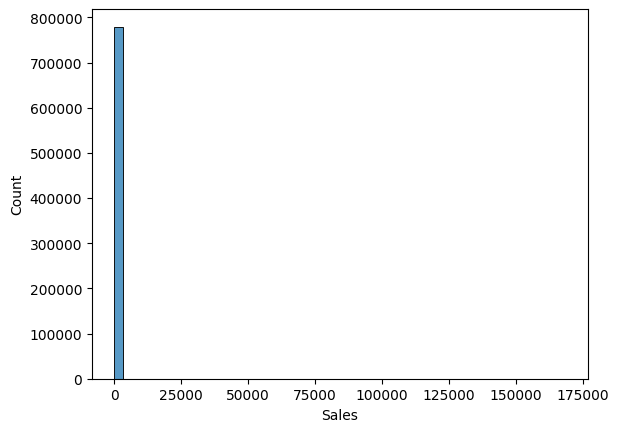

In [6]:
sns.histplot(df['Sales'], bins=50)
plt.show()

## RFM Analysis

### Calculate Snapshot Date

In [7]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

### Calculate RFM Metrics

In [12]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'Sales': 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']

## Create RFM Scores

### Recency Score 

In [13]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

### Frequency Score

In [14]:
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

### Monetary Score

In [15]:
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

### Generate RFM Score

In [16]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

### Customer Segmentation

In [17]:
def segment_customer(row):

    if row['R_Score'] >= 4 and row['F_Score'] >= 4:
        return 'Champions'

    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return 'Loyal Customers'

    elif row['R_Score'] >= 4 and row['F_Score'] <= 2:
        return 'Potential Loyalists'

    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk'

    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

### Segment Distribution

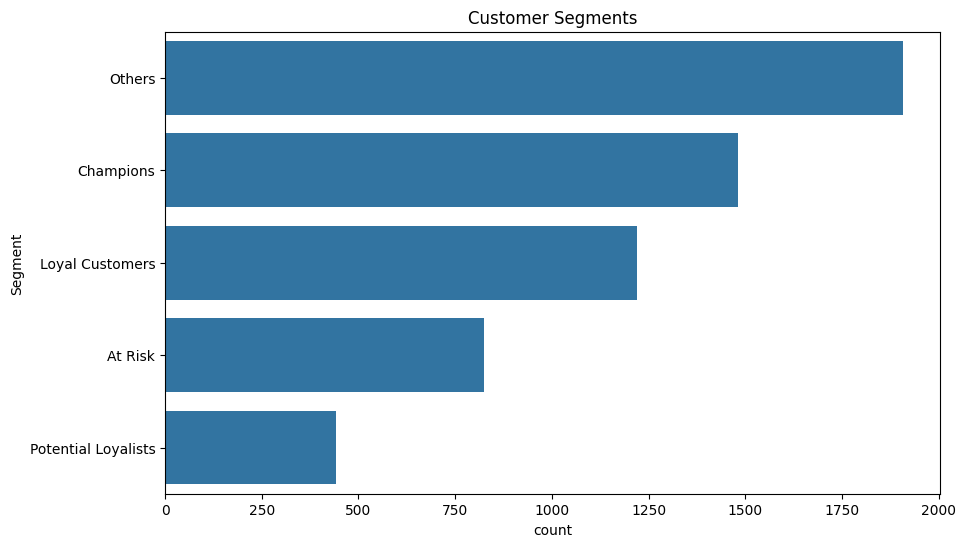

In [18]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='Segment',
    data=rfm,
    order=rfm['Segment'].value_counts().index
)

plt.title("Customer Segments")
plt.show()

## Cohort Analysis

### Create Cohort Month

In [19]:
df['InvoiceMonth'] = (
    df['InvoiceDate']
    .dt.to_period('M')
)

#### First purchase month:

In [21]:
df['CohortMonth'] = (
    df.groupby('Customer ID')['InvoiceMonth']
    .transform('min')
)

### Cohort Index

In [22]:
invoice_year = df['InvoiceDate'].dt.year
invoice_month = df['InvoiceDate'].dt.month

cohort_year = (
    df['CohortMonth'].dt.year
)

cohort_month = (
    df['CohortMonth'].dt.month
)

df['CohortIndex'] = (
    (invoice_year - cohort_year) * 12 +
    (invoice_month - cohort_month) + 1
)

## Cohort Table

In [24]:
cohort_data = (
    df.groupby(
        ['CohortMonth','CohortIndex']
    )['Customer ID']
    .nunique()
    .reset_index()
)

### Retention Matrix

In [25]:
cohort_counts = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='Customer ID'
)

cohort_sizes = cohort_counts.iloc[:,0]

retention = cohort_counts.divide(
    cohort_sizes,
    axis=0
)

## Cohort Retention Heatmap

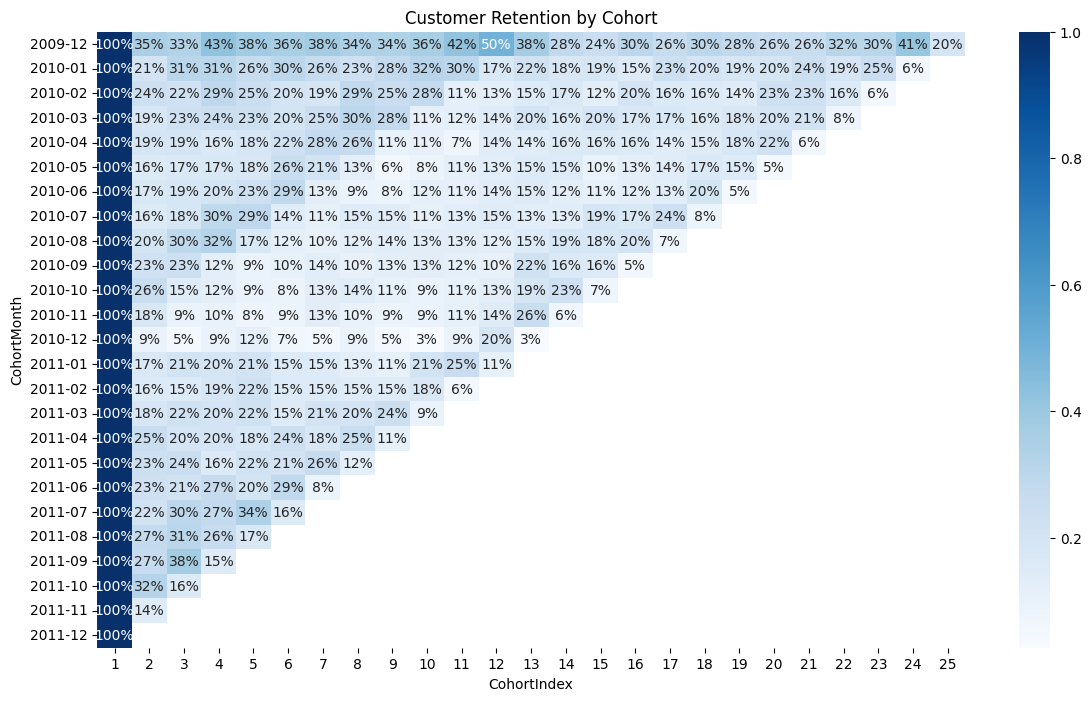

In [26]:
plt.figure(figsize=(14,8))

sns.heatmap(
    retention,
    annot=True,
    fmt='.0%',
    cmap='Blues'
)

plt.title("Customer Retention by Cohort")
plt.show()